# CardioIA: Fase 1 - Análise Exploratória de Dados (EDA) 📊🫀
Neste notebook, executaremos o ciclo completo de exploração, limpeza e visualização da nossa base de dados clínica (IoT) acoplada aos nossos exames de ECG (Visão Computacional).

In [2]:
!pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl (12.3 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3

## 1. Importação dos Dados
Carregando a base de dados em formato tabular estruturado `doencas_cardiacas.csv` gerada anteriormente.

In [3]:
df = pd.read_csv('doencas_cardiacas.csv')
display(df.head())
display(df.info())

,Imagem,Doença,Descrição,Sintomas,Tratamento,Idade,Nivel de glicemia,Pressão arterial,Nivel de colesterol,Oxigenação,Nivel de creatinina
0,asset/abnormal_heartbeat_ecg_images/HB(1).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",68,105 mg/dL,156/76,151 mg/dL,96 %,0.9 mg/dL
1,asset/abnormal_heartbeat_ecg_images/HB(10).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",32,85 mg/dL,141/89,218 mg/dL,95 %,0.8 mg/dL
2,asset/abnormal_heartbeat_ecg_images/HB(100).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",38,90 mg/dL,125/80,172 mg/dL,97 %,1.3 mg/dL
3,asset/abnormal_heartbeat_ecg_images/HB(101).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",39,106 mg/dL,137/74,191 mg/dL,97 %,1.1 mg/dL
4,asset/abnormal_heartbeat_ecg_images/HB(102).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",50,75 mg/dL,139/100,223 mg/dL,98 %,0.8 mg/dL


<class 'pandas.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Imagem               928 non-null    str  
 1   Doença               928 non-null    str  
 2   Descrição            928 non-null    str  
 3   Sintomas             928 non-null    str  
 4   Tratamento           928 non-null    str  
 5   Idade                928 non-null    int64
 6   Nivel de glicemia    928 non-null    str  
 7   Pressão arterial     928 non-null    str  
 8   Nivel de colesterol  928 non-null    str  
 9   Oxigenação           928 non-null    str  
 10  Nivel de creatinina  928 non-null    str  
dtypes: int64(1), str(10)
memory usage: 79.9 KB


None

## 2. Limpeza de Dados e Engenharia de Features (Data Wrangling)
A Governança e Qualidade dos dados exige tratamento na base. As variáveis clínicas brasião extraídas com sufixos ('mg/dL', '%') em colunas de texto (Strings/Objects). Iremos isolar as magnitudes matemáticas e convertê-las em *Floats*. Adicionalmente, vamos explodir a coluna de *Pressão Arterial* nas features *Sistólica* e *Diastólica*, cruciais para a análise de hipertensão em eventos extendsos.

In [4]:
# Remoção de Sufixos e Cast Type
df['Glicemia (mg/dL)'] = df['Nivel de glicemia'].str.replace(' mg/dL', '').astype(float)
df['Colesterol (mg/dL)'] = df['Nivel de colesterol'].str.replace(' mg/dL', '').astype(float)
df['Oxigenacao (%)'] = df['Oxigenação'].str.replace(' %', '').astype(float)
df['Creatinina (mg/dL)'] = df['Nivel de creatinina'].str.replace(' mg/dL', '').astype(float)

# Split Feature Pressão Arterial
df[['Pressao_Sistolica', 'Pressao_Diastolica']] = df['Pressão arterial'].str.split('/', expand=True).astype(float)

# Drop das features antigas
df.drop(columns=['Nivel de glicemia', 'Nivel de colesterol', 'Oxigenação', 'Nivel de creatinina', 'Pressão arterial'], inplace=True)

df.head()

,Imagem,Doença,Descrição,Sintomas,Tratamento,Idade,Glicemia (mg/dL),Colesterol (mg/dL),Oxigenacao (%),Creatinina (mg/dL),Pressao_Sistolica,Pressao_Diastolica
0,asset/abnormal_heartbeat_ecg_images/HB(1).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",68,105.0,151.0,96.0,0.9,156.0,76.0
1,asset/abnormal_heartbeat_ecg_images/HB(10).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",32,85.0,218.0,95.0,0.8,141.0,89.0
2,asset/abnormal_heartbeat_ecg_images/HB(100).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",38,90.0,172.0,97.0,1.3,125.0,80.0
3,asset/abnormal_heartbeat_ecg_images/HB(101).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",39,106.0,191.0,97.0,1.1,137.0,74.0
4,asset/abnormal_heartbeat_ecg_images/HB(102).jpg,Arritmia Cardíaca,"Ritmo cardíaco irregular, podendo bater muito ...","Palpitações, falta de ar, tontura, desconforto...","Betabloqueadores, antiarrítmicos, ablação por ...",50,75.0,223.0,98.0,0.8,139.0,100.0


## 3. Análise Estatística (Descritiva e Diagnóstica)
Avaliação das distribuições métricas dos pacientes em nossos grupos de dados numéricos coletados.

In [5]:
df.describe()

,Idade,Glicemia (mg/dL),Colesterol (mg/dL),Oxigenacao (%),Creatinina (mg/dL),Pressao_Sistolica,Pressao_Diastolica
count,928.000000,928.000000,928.000000,928.000000,928.000000,928.00000,928.000000
mean,58.056034,105.471983,190.871767,95.409483,1.102047,132.81681,84.433190
std,18.638880,26.291973,44.814032,3.976250,0.313084,18.27339,10.556973
min,20.000000,70.000000,121.000000,85.000000,0.600000,110.00000,70.000000
25%,45.000000,86.000000,154.000000,94.000000,0.900000,118.00000,76.000000
50%,57.000000,98.000000,183.000000,96.000000,1.000000,127.00000,82.000000
75%,74.000000,118.000000,221.500000,98.000000,1.300000,145.00000,92.000000
max,95.000000,180.000000,300.000000,100.000000,2.000000,180.00000,110.000000


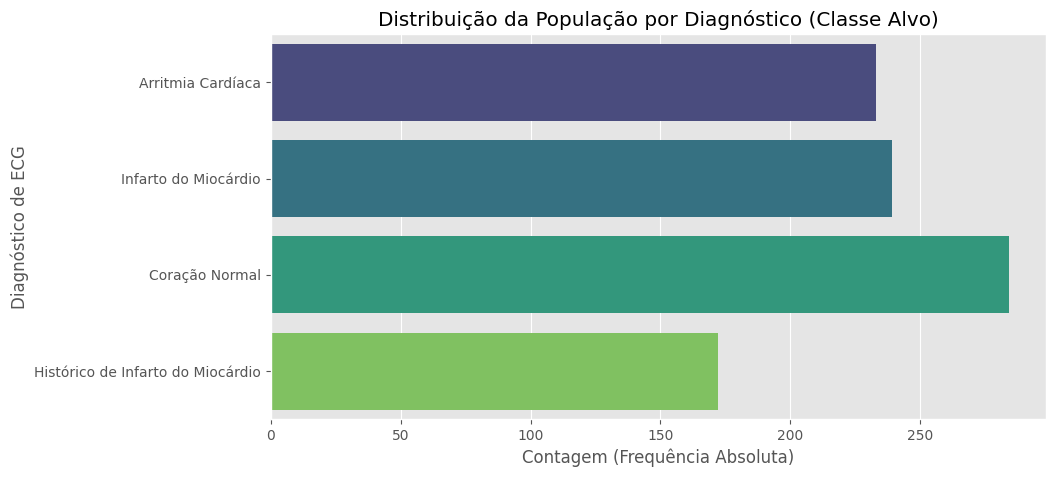

In [6]:
# Balanceamento das Classes / Doenças
plt.figure(figsize=(10, 5))
sns.countplot(y='Doença', data=df, palette='viridis')
plt.title('Distribuição da População por Diagnóstico (Classe Alvo)')
plt.xlabel('Contagem (Frequência Absoluta)')
plt.ylabel('Diagnóstico de ECG')
plt.show()

### Distribuições Probabilísticas (Kernel Density Estimation - KDE)
É importante observar as métricas globais para encontrar *outliers*, *skewness* e o formatamento Gaussiano (Distribuição Normal) entre as métricas de saúde.

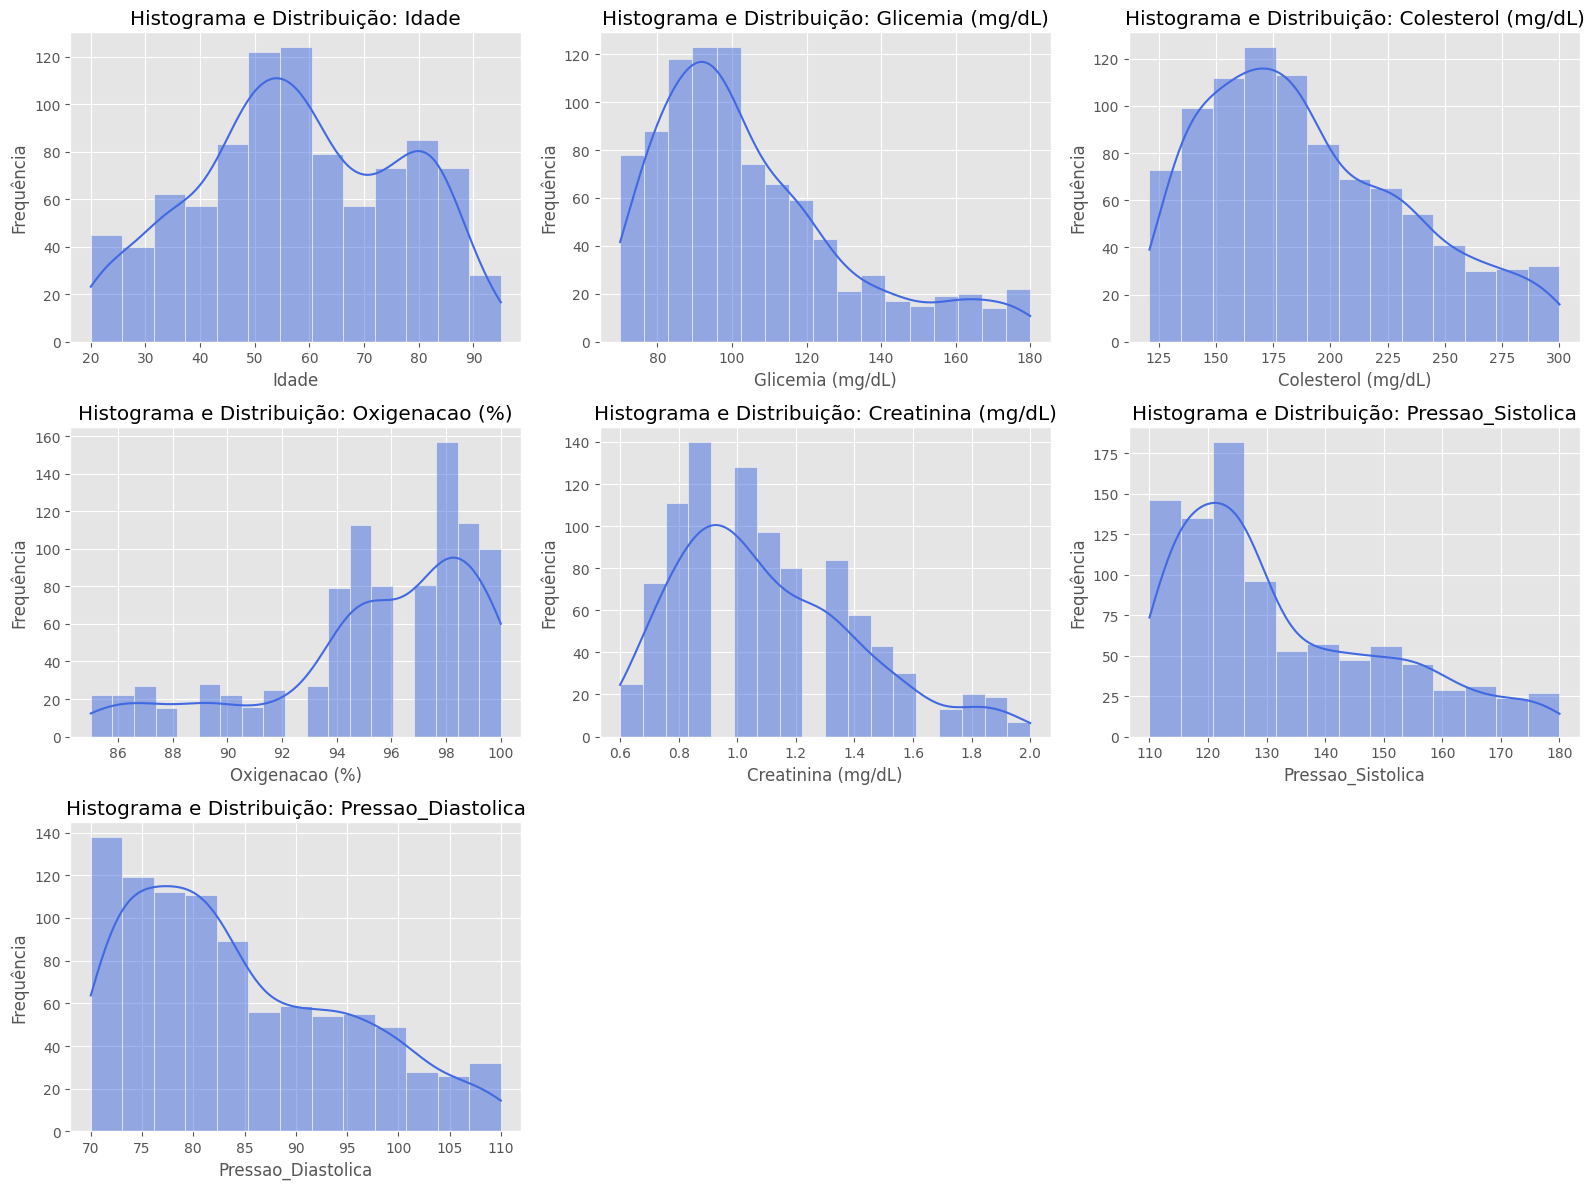

In [7]:
metricas_clinicas = ['Idade', 'Glicemia (mg/dL)', 'Colesterol (mg/dL)', 
                     'Oxigenacao (%)', 'Creatinina (mg/dL)', 
                     'Pressao_Sistolica', 'Pressao_Diastolica']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(metricas_clinicas):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='royalblue')
    axes[idx].set_title(f'Histograma e Distribuição: {col}')
    axes[idx].set_ylabel('Frequência')

# Apaga Eixos Extras
for j in range(len(metricas_clinicas), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Boxplots Clínicos e Identificação de Comportamentos Preditivos 
Como os nossos grupos diferem entre o envelhecimento natural do ser humano versus o desgaste endotelial pressórico?

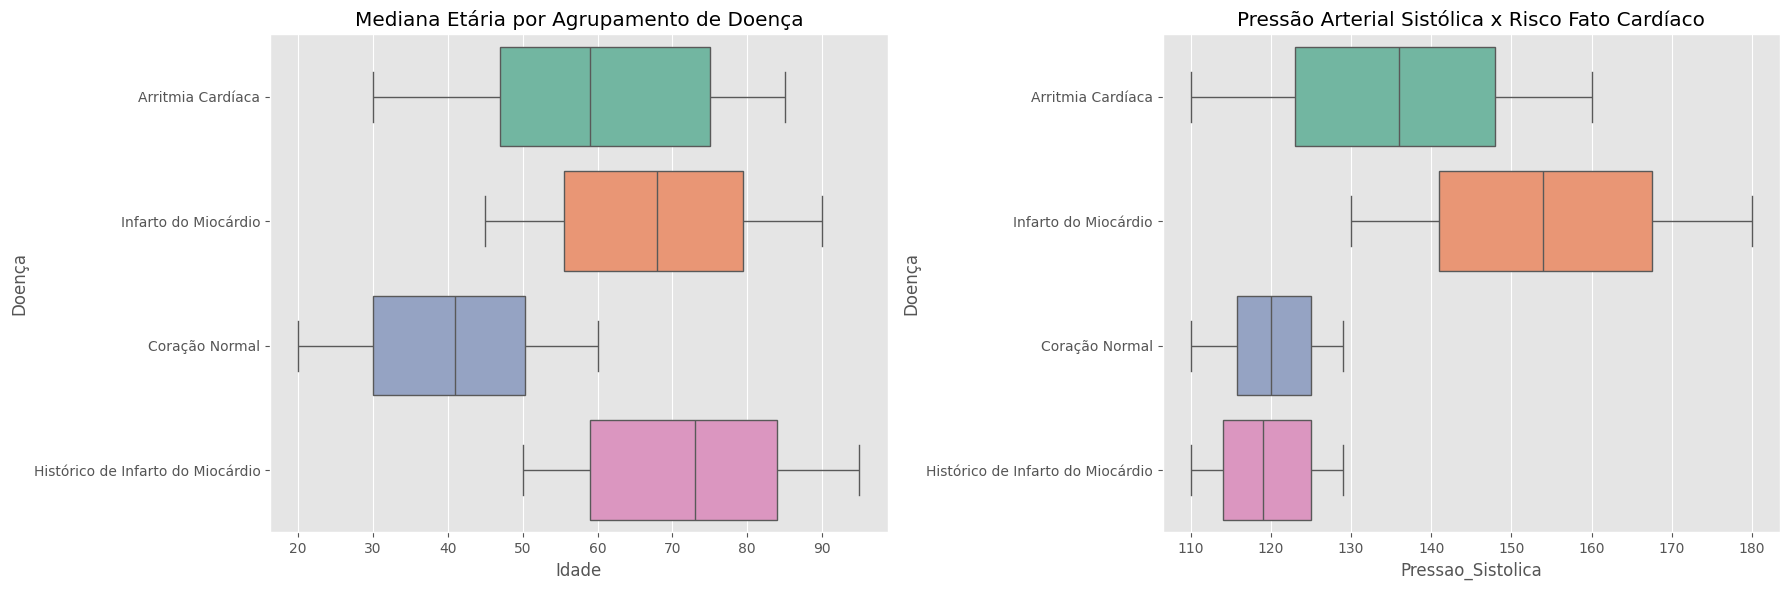

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Correlacionando Idade e Grupos de Risco
sns.boxplot(x='Idade', y='Doença', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Mediana Etária por Agrupamento de Doença')

# Correlacionando Estresse Sistólico e Doença
sns.boxplot(x='Pressao_Sistolica', y='Doença', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Pressão Arterial Sistólica x Risco Fato Cardíaco')

plt.tight_layout()
plt.show()

## 4. Exploração Visão Computacional (Deep Learning Data Pipeline)
Para modelos como CNNs, validar a integridade dos artefatos visuais extraídos contra o label rotulado no Dataframe é passo imperativo de uma governança de dados limpa.

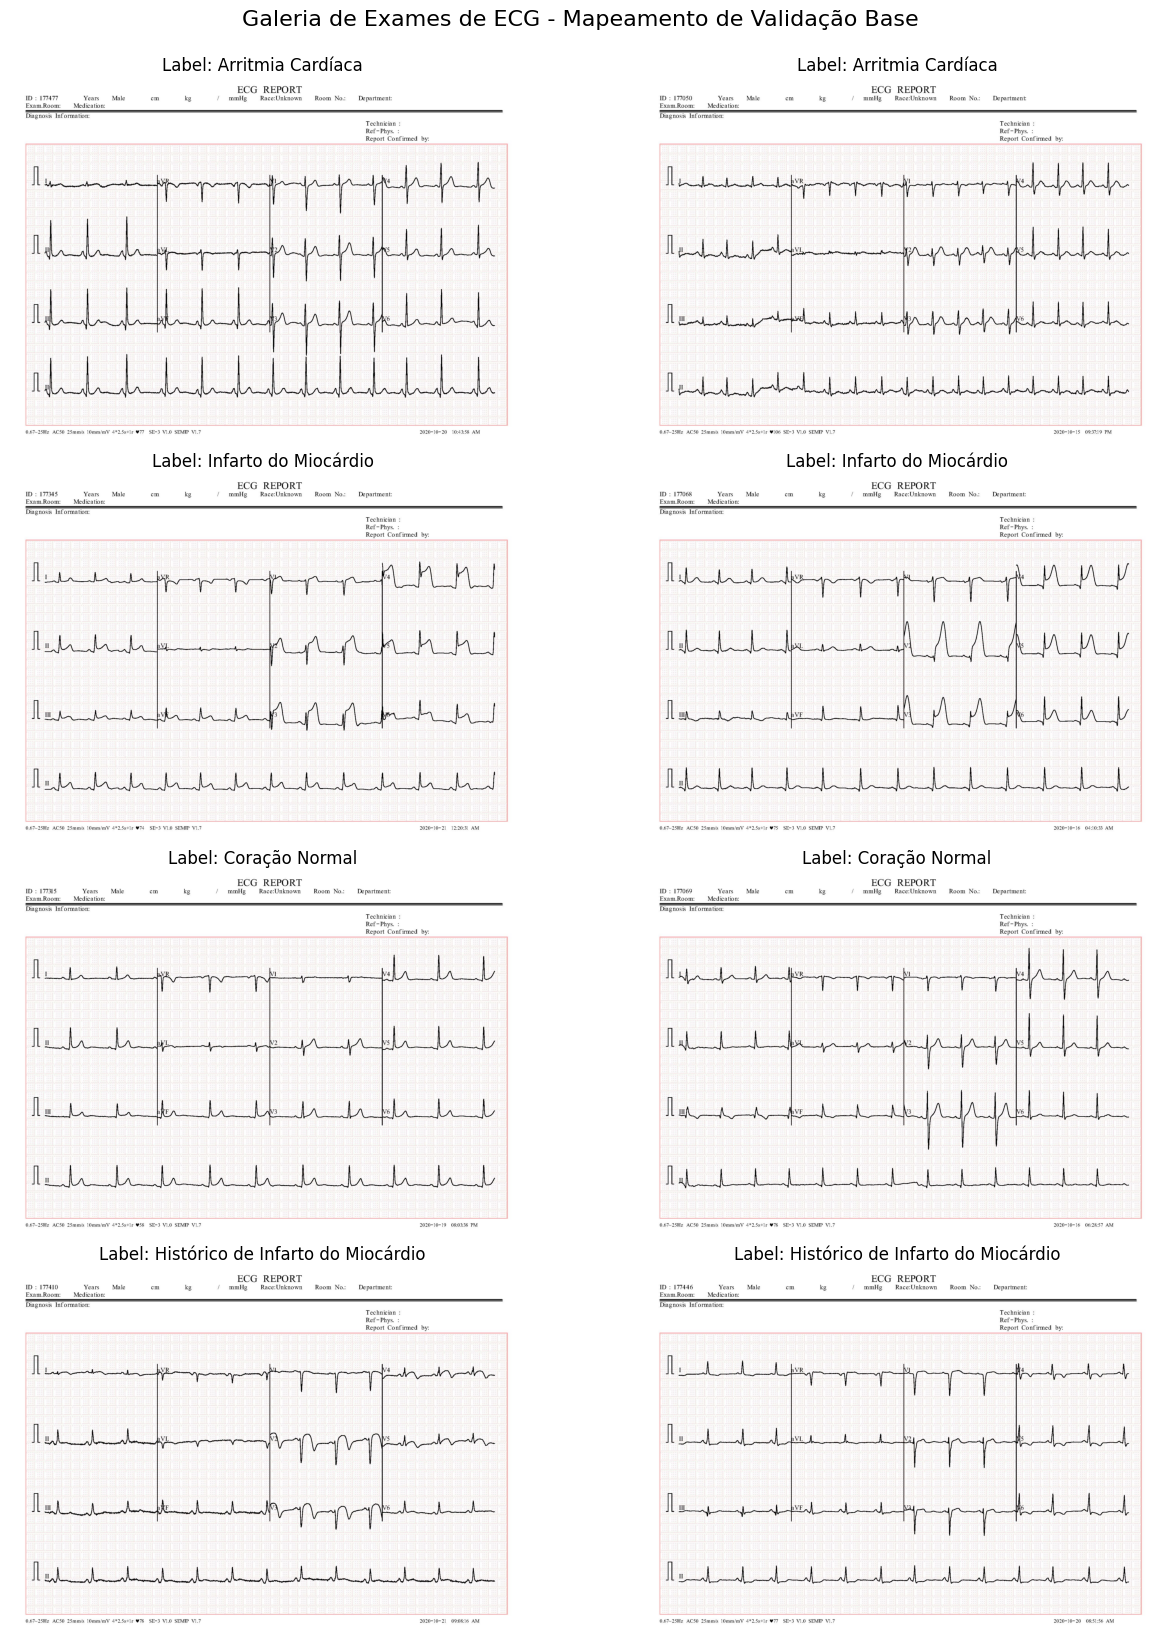

In [9]:
def mount_ecg_gallery(dataset, features_count=2):
    classes_diagnosticas = dataset['Doença'].unique()
    fig, axes = plt.subplots(len(classes_diagnosticas), features_count, figsize=(14, 4 * len(classes_diagnosticas)))
    
    if features_count == 1:
         axes = np.array(axes).reshape(-1, 1)

    for i, dx in enumerate(classes_diagnosticas):
        amostras = dataset[dataset['Doença'] == dx].sample(n=features_count, random_state=42)['Imagem'].values
        for j, im_path in enumerate(amostras):
            if os.path.exists(im_path):
                img = Image.open(im_path)
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"Label: {dx}", fontsize=12)
                axes[i, j].axis('off')
            else:
                axes[i, j].set_title(f"Broken Path:\n{im_path}")
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.suptitle("Galeria de Exames de ECG - Mapeamento de Validação Base", y=1.02, fontsize=16)
    plt.show()

mount_ecg_gallery(df, features_count=2)